# Environment Setup


In [1]:
import numpy as np # linear algebra
from google.colab import drive
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown
import kagglehub
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
drive.mount('/content/drive')

Mounted at /content/drive


#Data Splitting

##Dual stream dataset

In [6]:
# Define the dual-stream dataset with separate transforms.
class DualStreamDataset(Dataset):
    def __init__(self, org_dir, kmeans_dir, transform_org=None, transform_kmeans=None):
        self.org_dir = org_dir
        self.kmeans_dir = kmeans_dir
        self.transform_org = transform_org
        self.transform_kmeans = transform_kmeans
        self.samples = []

        # Get sorted class names (folder names)
        classes = sorted([d for d in os.listdir(org_dir)
                          if os.path.isdir(os.path.join(org_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        self.classes = classes

        # Loop through each class directory and collect file paths.
        for cls in classes:
            org_class_dir = os.path.join(org_dir, cls)
            kmeans_class_dir = os.path.join(kmeans_dir, cls)
            for fname in os.listdir(org_class_dir):
                if fname.lower().endswith('.jpg'):
                    base_name = os.path.splitext(fname)[0]
                    kmeans_fname = f"{base_name}_final_masked.jpg"
                    org_path = os.path.join(org_class_dir, fname)
                    kmeans_path = os.path.join(kmeans_class_dir, kmeans_fname)
                    if os.path.exists(kmeans_path):
                        label = self.class_to_idx[cls]
                        self.samples.append((org_path, kmeans_path, label))
                    else:
                        print(f"Warning: {kmeans_path} not found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        org_path, kmeans_path, label = self.samples[index]
        org_image = Image.open(org_path).convert('RGB')
        kmeans_image = Image.open(kmeans_path).convert('RGB')

        # Apply transforms: original image gets augmentation; k-means gets basic transform.
        if self.transform_org:
            org_image = self.transform_org(org_image)
        if self.transform_kmeans:
            kmeans_image = self.transform_kmeans(kmeans_image)

        return org_image, kmeans_image, label

##Original Image Transform

In [7]:
# Define transform for original images: apply random rotation and color jittering.
org_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Apply color jittering
    T.Resize((224, 224)),  # Resize image to 224x224
    T.ToTensor()  # Convert PIL image to tensor (without normalization)
])

##K-mean image transform

In [8]:
# Define basic transform for k-means images (only resize and convert to tensor).
kmeans_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

##Create dataset

In [9]:
# Create the dataset instance.
dataset = DualStreamDataset(
    org_dir="/content/drive/MyDrive/tomato_dataset/color",      # Replace with your original image directory
    kmeans_dir="/content/drive/MyDrive/tomato_dataset/kmean_clustered",  # Replace with your k-means image directory
    transform_org=org_transform,
    transform_kmeans=kmeans_transform
)

# Split dataset into train (80%), validation (10%), and test (10%) sets.
total_samples = len(dataset)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


##Verify result (Optional)

In [10]:
# Example: iterate through one batch from the training loader and print shapes.
for org_img, kmeans_img, labels in train_loader:
    print("Original image batch shape:", org_img.shape)
    print("K-means image batch shape:", kmeans_img.shape)
    print("Labels:", labels)
    break

Original image batch shape: torch.Size([32, 3, 224, 224])
K-means image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([7, 7, 7, 7, 7, 2, 7, 4, 7, 4, 7, 3, 7, 2, 2, 9, 7, 2, 1, 4, 9, 2, 9, 9,
        6, 2, 7, 7, 0, 1, 9, 7])


## Display data sample

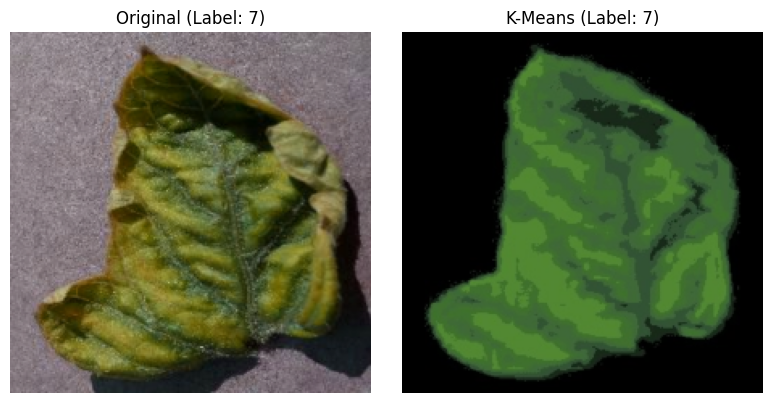

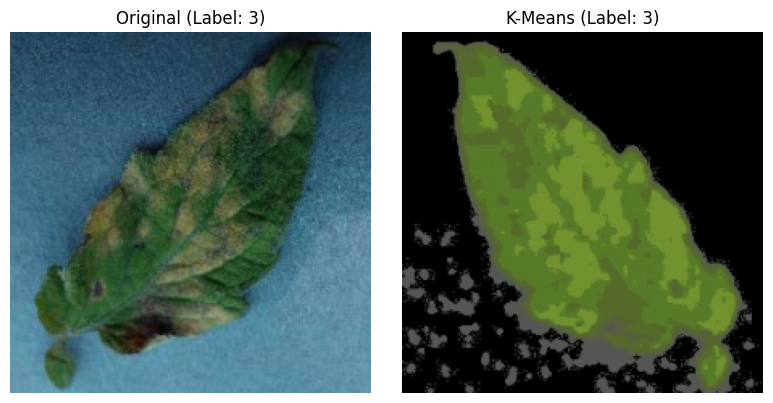

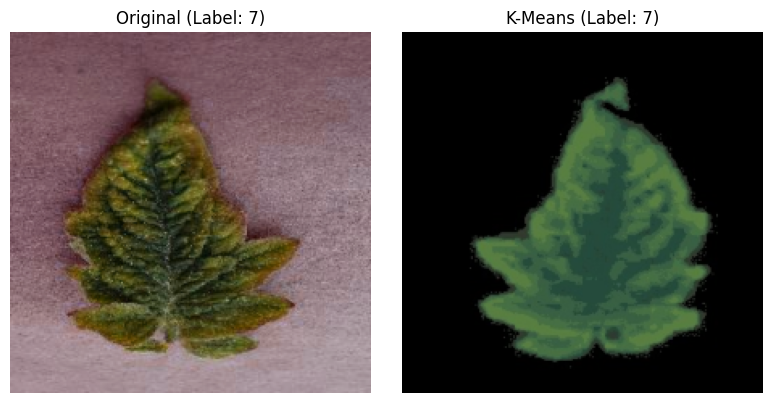

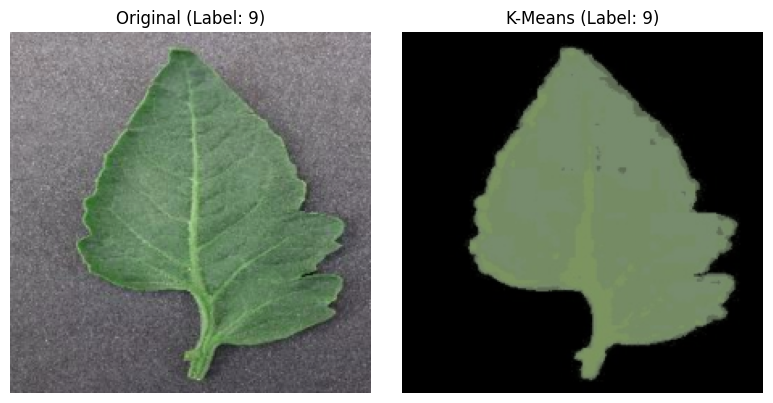

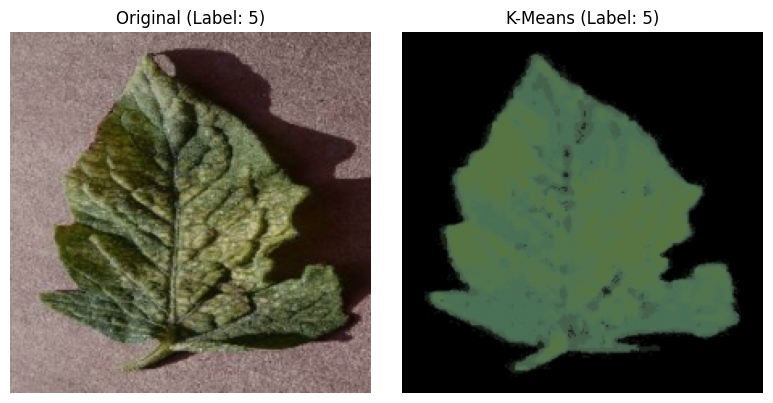

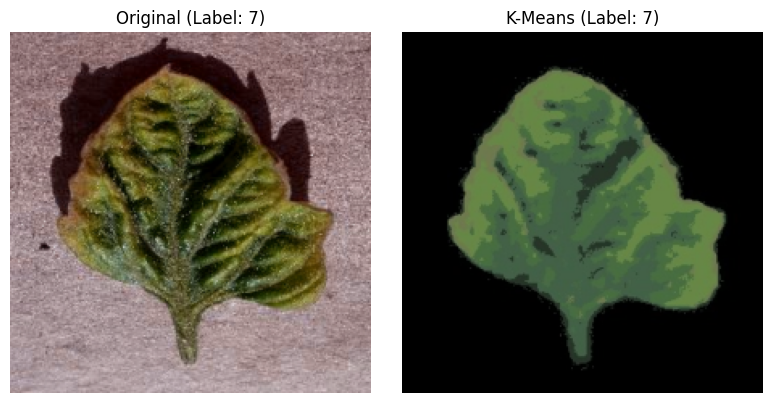

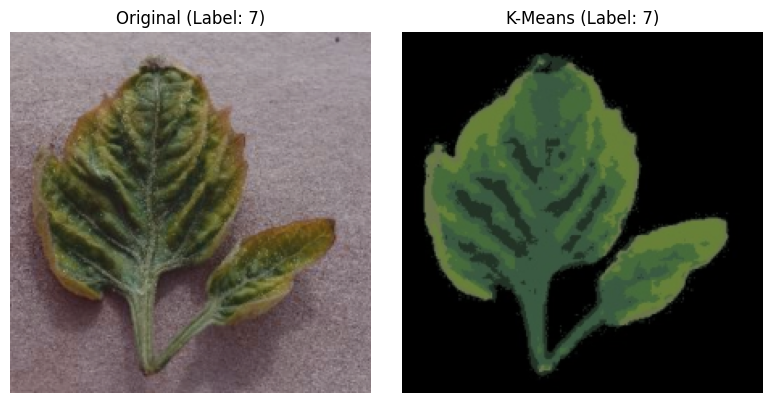

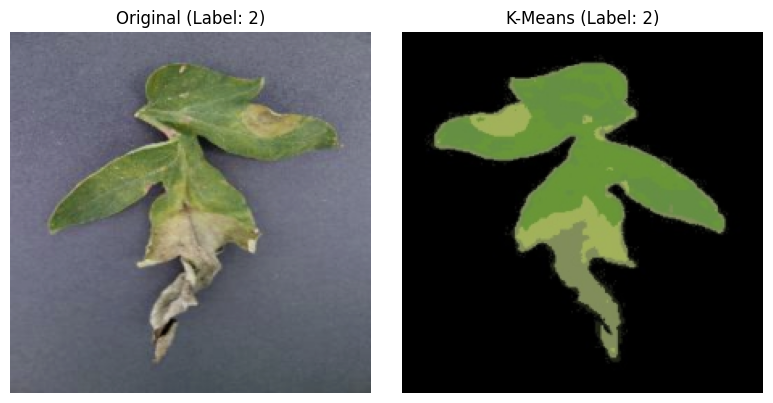

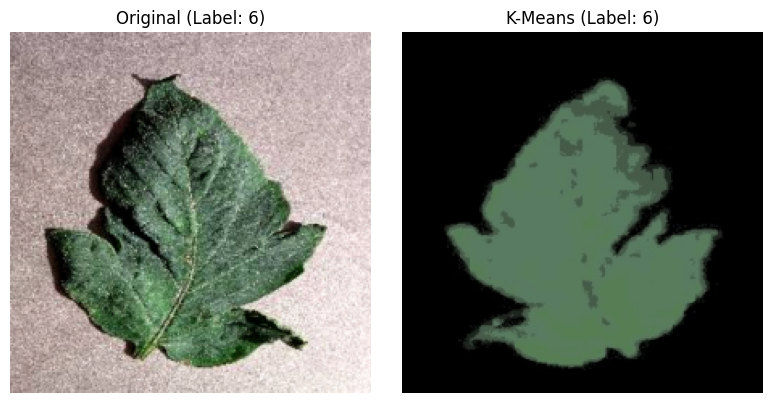

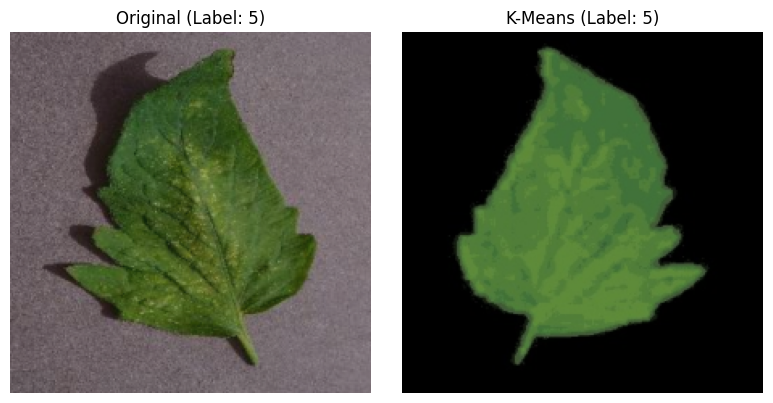

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose you already have a train_loader:
# train_loader = DataLoader(train_dataset, ...)

# Grab one batch of data from the loader.
data_iter = iter(train_loader)
org_batch, kmeans_batch, labels = next(data_iter)

# If you have a list of class names from your dataset, you can use it for a nicer title.
# For example:
# class_names = dataset.classes  # If your dataset has an attribute .classes
class_names = None  # Or replace with the actual class list

# Let's display the first 10 samples in the batch (or fewer if batch_size < 10).
num_to_show = min(10, org_batch.size(0))

def denormalize_and_convert(img_tensor):
    """
    Optional helper to convert a normalized tensor (C,H,W) to a NumPy (H,W,C) for display.
    If you used mean/std normalization, you can unnormalize here.
    """
    # Example for standard ImageNet mean/std:
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    #
    # img_tensor = img_tensor * torch.tensor(std).view(3,1,1)
    # img_tensor = img_tensor + torch.tensor(mean).view(3,1,1)

    # Convert from (C, H, W) to (H, W, C) and clamp to valid range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    return img_np

for i in range(num_to_show):
    org_img = denormalize_and_convert(org_batch[i])
    kmeans_img = denormalize_and_convert(kmeans_batch[i])
    label_idx = labels[i].item()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Show original image
    axs[0].imshow(org_img)
    if class_names is not None:
        axs[0].set_title(f"Original (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[0].set_title(f"Original (Label: {label_idx})")
    axs[0].axis('off')

    # Show k-means image
    axs[1].imshow(kmeans_img)
    if class_names is not None:
        axs[1].set_title(f"K-Means (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[1].set_title(f"K-Means (Label: {label_idx})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


In [12]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [14]:
#Check consistency
import os

folder_path = "/content/drive/MyDrive/tomato_dataset/kmean_clustered/Tomato___Bacterial_spot"
# List all entries in the folder
entries = os.listdir(folder_path)
# Filter only files (not directories)
files = [f for f in entries if os.path.isfile(os.path.join(folder_path, f))]
print("Number of files:", len(files))

Number of files: 2127


# Check and Perform Ablation

## check num stage and block

In [15]:
import timm

model = timm.create_model("levit_192", pretrained=True, num_classes=0)
print("Number of stages:", len(model.stages))
for i, stage in enumerate(model.stages):
    # Assuming each stage has an attribute 'blocks'
    print(f"Stage {i}: {len(stage.blocks)} blocks")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/44.2M [00:00<?, ?B/s]

Number of stages: 3
Stage 0: 4 blocks
Stage 1: 4 blocks
Stage 2: 4 blocks


In [16]:
import timm

# Create an instance of the LeViT-192 model from timm.
model = timm.create_model("levit_192", pretrained=True, num_classes=0)

print("Model structure details:")
print("-" * 40)
print("Stem layers (initial convolutions):")
for name, module in model.named_children():
    print(name, ":", module.__class__.__name__)

print("\nStages:")
for stage_idx, stage in enumerate(model.stages):
    print(f"Stage {stage_idx}:")
    # Each stage usually has a 'downsample' (or Identity) and 'blocks'
    for subname, submodule in stage.named_children():
        print(f"  {subname}: {submodule.__class__.__name__}")
    # Now loop over each block in the stage
    for block_idx, block in enumerate(stage.blocks):
        print(f"    Block {block_idx}: {block.__class__.__name__}")
        # To inspect major submodules of a block, you might print the following:
        if hasattr(block, "attn"):
            print(f"      attn: {block.attn.__class__.__name__}")
        if hasattr(block, "mlp"):
            print(f"      mlp: {block.mlp.__class__.__name__}")
        # Additional details (like drop paths or normalization) may be included based on the timm implementation.


Model structure details:
----------------------------------------
Stem layers (initial convolutions):
stem : Stem16
stages : Sequential
head : Identity
head_dist : Identity

Stages:
Stage 0:
  downsample: Identity
  blocks: Sequential
    Block 0: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 1: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 2: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 3: LevitBlock
      attn: Attention
      mlp: LevitMlp
Stage 1:
  downsample: LevitDownsample
  blocks: Sequential
    Block 0: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 1: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 2: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 3: LevitBlock
      attn: Attention
      mlp: LevitMlp
Stage 2:
  downsample: LevitDownsample
  blocks: Sequential
    Block 0: LevitBlock
      attn: Attention
      mlp: LevitMlp
    Block 1: LevitBlock
      attn: Attention
     

In [17]:
import numpy as np
from torch.utils.data import Subset, random_split, DataLoader

# Create the dataset instance.
dataset = DualStreamDataset(
    org_dir="/content/drive/MyDrive/tomato_dataset/color",      # Replace with your original image directory
    kmeans_dir="/content/drive/MyDrive/tomato_dataset/kmean_clustered",  # Replace with your k-means image directory
    transform_org=org_transform,
    transform_kmeans=kmeans_transform
)

# Split dataset into train (70%), validation (15%), and test (15%) sets.
total_samples = len(dataset)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])



# Create DataLoaders for each split.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


##varify if the dataloader is correct (the dual stream dataset are paired)

In [18]:
# Example: iterate through one batch from the training loader and print shapes.
for org_img, kmeans_img, labels in train_loader:
    print("Original image batch shape:", org_img.shape)
    print("K-means image batch shape:", kmeans_img.shape)
    print("Labels:", labels)
    break

Original image batch shape: torch.Size([32, 3, 224, 224])
K-means image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([4, 0, 2, 1, 1, 0, 0, 7, 0, 7, 0, 7, 9, 7, 4, 0, 7, 4, 2, 7, 7, 7, 7, 4,
        6, 4, 6, 4, 1, 0, 7, 0])


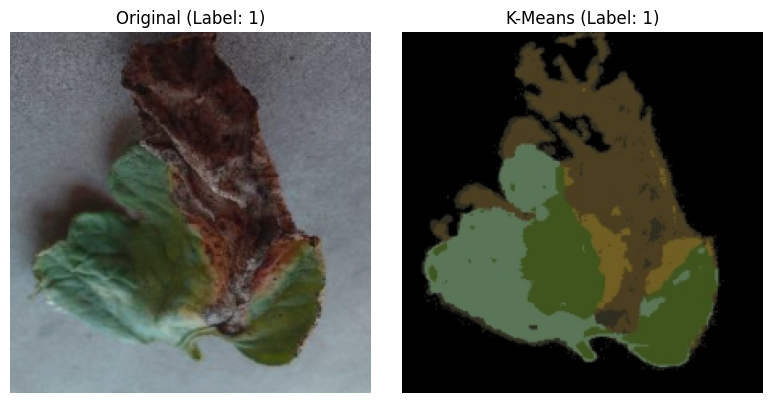

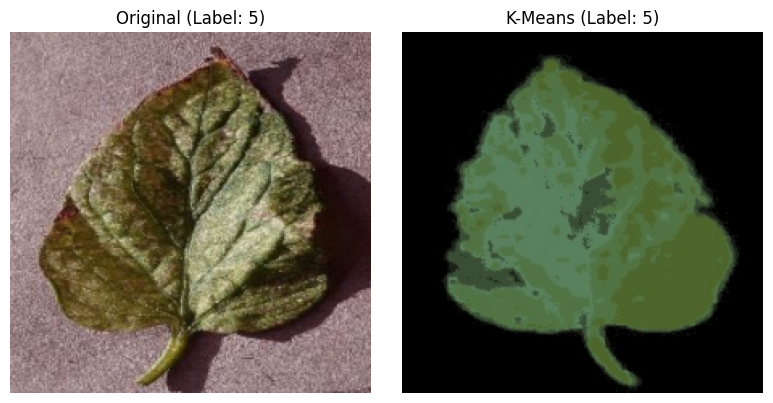

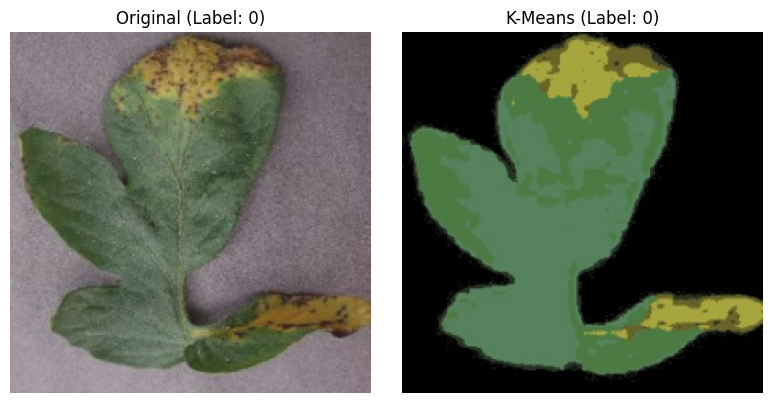

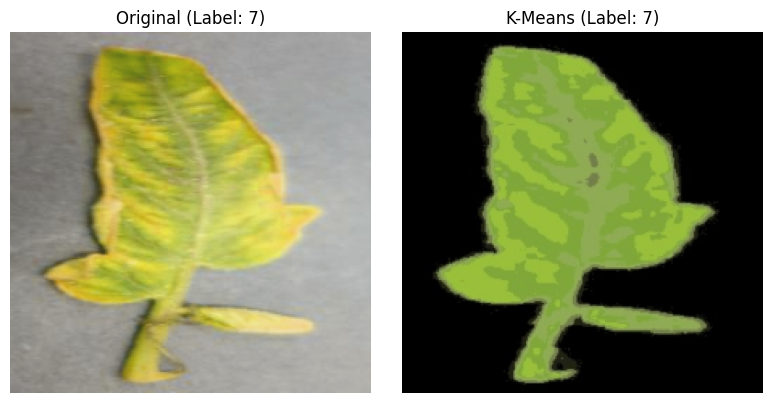

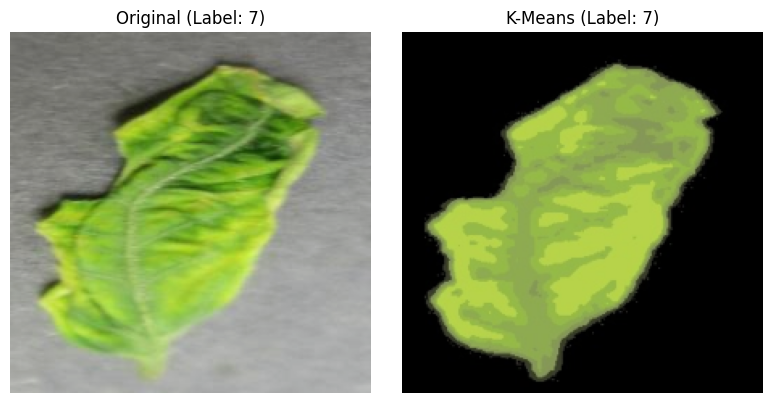

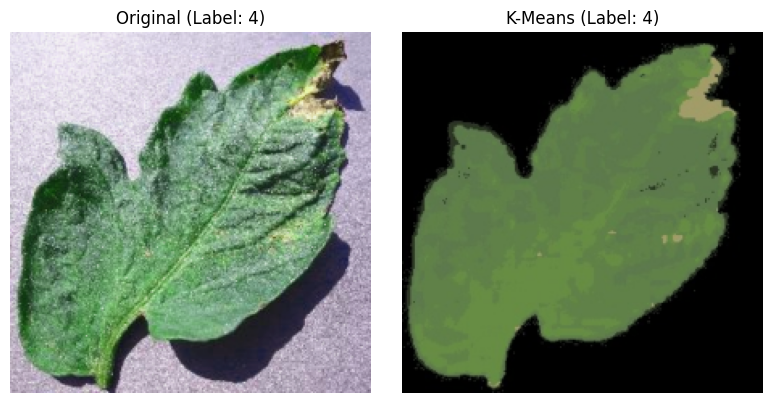

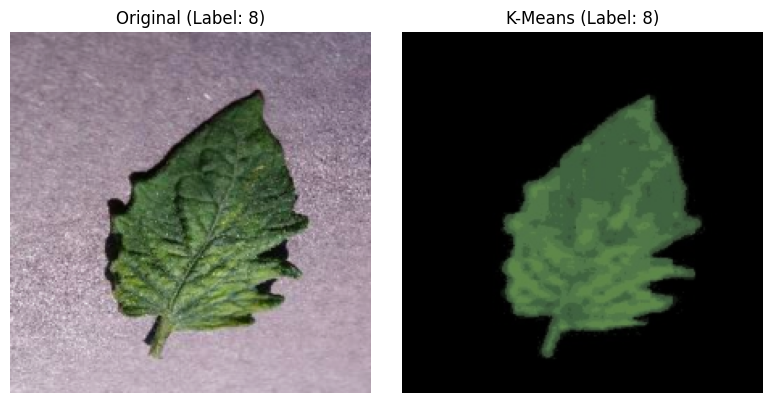

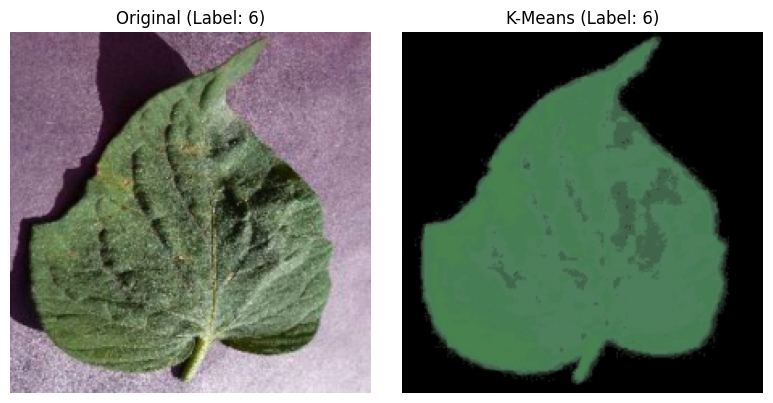

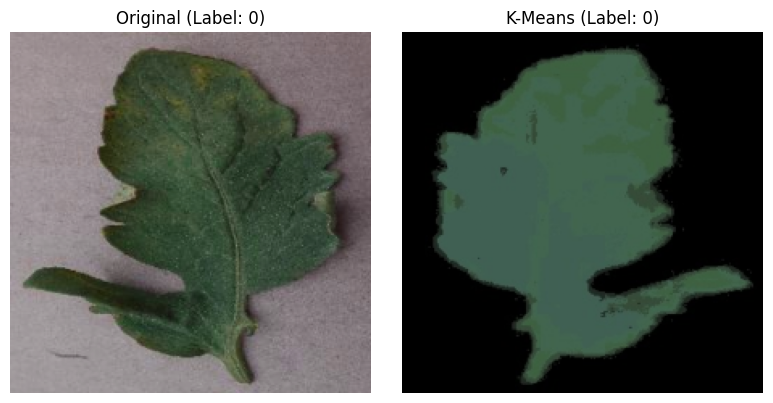

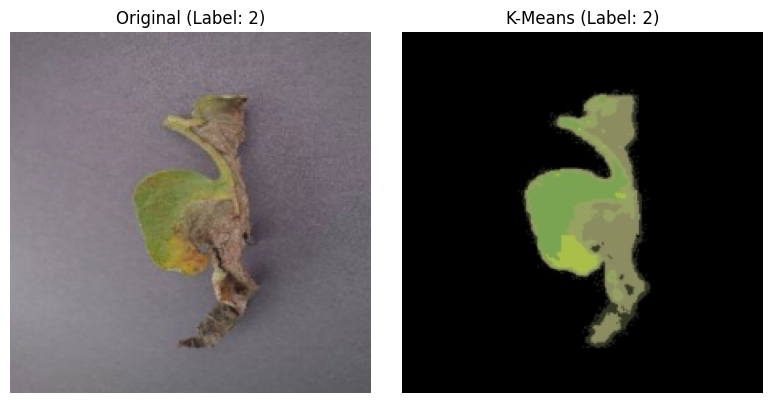

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose you already have a train_loader:
# train_loader = DataLoader(train_dataset, ...)

# Grab one batch of data from the loader.
data_iter = iter(train_loader)
org_batch, kmeans_batch, labels = next(data_iter)

# If you have a list of class names from your dataset, you can use it for a nicer title.
# For example:
# class_names = dataset.classes  # If your dataset has an attribute .classes
class_names = None  # Or replace with the actual class list

# Let's display the first 10 samples in the batch (or fewer if batch_size < 10).
num_to_show = min(10, org_batch.size(0))

def denormalize_and_convert(img_tensor):
    """
    Optional helper to convert a normalized tensor (C,H,W) to a NumPy (H,W,C) for display.
    If you used mean/std normalization, you can unnormalize here.
    """
    # Example for standard ImageNet mean/std:
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    #
    # img_tensor = img_tensor * torch.tensor(std).view(3,1,1)
    # img_tensor = img_tensor + torch.tensor(mean).view(3,1,1)

    # Convert from (C, H, W) to (H, W, C) and clamp to valid range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    return img_np

for i in range(num_to_show):
    org_img = denormalize_and_convert(org_batch[i])
    kmeans_img = denormalize_and_convert(kmeans_batch[i])
    label_idx = labels[i].item()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Show original image
    axs[0].imshow(org_img)
    if class_names is not None:
        axs[0].set_title(f"Original (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[0].set_title(f"Original (Label: {label_idx})")
    axs[0].axis('off')

    # Show k-means image
    axs[1].imshow(kmeans_img)
    if class_names is not None:
        axs[1].set_title(f"K-Means (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[1].set_title(f"K-Means (Label: {label_idx})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


## Ablation of LeViT-192 Components

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import copy
from tqdm import tqdm
import numpy as np
import os

# -----------------------------
# 1. Define the Fusion MLP
# -----------------------------
class FusionMLP(nn.Module):
    def __init__(self, input_dim=768, hidden_dims=[512, 256], num_classes=10):
        """
        Constructs a multilayer perceptron to fuse features from the two LeViT streams.
        Input dimension is 768 because each stream outputs a 384-dim vector.
        """
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        # Create fully connected layers with ReLU activation and dropout.
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        layers.append(nn.Linear(in_dim, num_classes))
        # Sequential module for the MLP.
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the fusion MLP.
        return self.mlp(x)

# -----------------------------
# 2. Define the Dual-Stream LeViT Model
# -----------------------------
class DualStreamLeViT(nn.Module):
    def __init__(self, num_classes=10):
        """
        Constructs the dual-stream LeViT-192 model.
        Each stream uses a pretrained LeViT-192 (with num_classes=0 for feature extraction),
        and their outputs (each of dimension 384) are concatenated to form a 768-dim feature
        vector which is then fed into the FusionMLP for classification.
        """
        super(DualStreamLeViT, self).__init__()
        # Load the LeViT-192 model from timm, which includes a convolutional stem,
        # three transformer stages (each with several LevitBlocks), and a classification head.
        # Here, we set num_classes=0 so that each stream outputs feature embeddings.
        self.stream1 = timm.create_model("levit_192", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("levit_192", pretrained=True, num_classes=0)
        # The fusion MLP takes the concatenated features from both streams.
        self.fusion_mlp = FusionMLP(input_dim=768, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Forward pass for each stream. Each stream outputs a 384-dim vector.
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 384]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 384]
        # Concatenate features from both streams to form a 768-dim vector.
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 768]
        # Pass fused features through the fusion MLP to obtain final logits.
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# -----------------------------
# 3. Define a Function to Mask All Target Components in the Model
# -----------------------------
def mask_all_components(model, target="block", mask_type="identity"):
    """
    Masks all target components in both streams of the given model.

    In our ablation study (see report), we consider three targets for masking:
      - "block": This masks the entire LevitBlock (aka Shrink Attention Block).
      - "attn": This masks only the Attention module within each block (the MHSA Block).
      - "mlp": This masks only the MLP module within each block (the MLP Block).

    Masking here means replacing the forward function with an identity mapping.
    The parameter mask_type, set to "identity", ensures that the module output is exactly
    the input, thereby bypassing any learned transformation.

    Parameters:
      model: an instance of DualStreamLeViT.
      target: one of "block", "attn", or "mlp".
      mask_type: using "identity" ensures the output is passed unchanged.
    """
    # Identity function: returns input without change.
    identity_fn = lambda x, *args, **kwargs: x

    # Iterate over both streams in the model.
    for stream in [model.stream1, model.stream2]:
        # Each stream has multiple stages.
        for stage in stream.stages:
            # Each stage contains a sequence of blocks.
            for block in stage.blocks:
                if target == "block":
                    # Mask the entire block: treat the block as a direct passthrough.
                    block.forward = identity_fn
                elif target == "attn":
                    # Mask only the attention module (MHSA Block).
                    if hasattr(block, "attn"):
                        block.attn.forward = identity_fn
                    else:
                        print("Block missing 'attn' submodule.")
                elif target == "mlp":
                    # Mask only the MLP module.
                    if hasattr(block, "mlp"):
                        block.mlp.forward = identity_fn
                    else:
                        print("Block missing 'mlp' submodule.")
                else:
                    raise ValueError("Unknown target. Use 'block', 'attn', or 'mlp'.")

# -----------------------------
# 4. Define Training, Validation, and Test Functions
# -----------------------------
def train_and_evaluate(model, train_loader, val_loader, device, num_epochs=40, patience=10, checkpoint_path='best_model.pth'):
    """
    Train the model for a fixed number of epochs with early stopping and then evaluate it on the
    validation set. The model is saved when the validation loss decreases.

    Returns the best validation accuracy achieved.
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Learning rate set to 1e-3 as required
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
        for orig_imgs, kmeans_imgs, labels in train_bar:
            orig_imgs = orig_imgs.to(device)
            kmeans_imgs = kmeans_imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(orig_imgs, kmeans_imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            train_bar.set_postfix(loss=loss.item())

        train_loss = running_loss / total_train
        train_acc = correct_train / total_train

        # Validation phase.
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        all_preds = []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
        with torch.no_grad():
            for orig_imgs, kmeans_imgs, labels in val_bar:
                orig_imgs = orig_imgs.to(device)
                kmeans_imgs = kmeans_imgs.to(device)
                labels = labels.to(device)

                logits = model(orig_imgs, kmeans_imgs)
                loss_val = criterion(logits, labels)

                running_val_loss += loss_val.item() * labels.size(0)
                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
                all_preds.append(preds.cpu())
                val_bar.set_postfix(loss=loss_val.item())

        val_loss = running_val_loss / total_val
        val_acc = correct_val / total_val

        # Compute distribution of predicted classes.
        all_preds = torch.cat(all_preds)
        unique, counts = torch.unique(all_preds, return_counts=True)
        pred_distribution = dict(zip(unique.tolist(), counts.tolist()))

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f} | Pred Dist: {pred_distribution}")

        # Check if current epoch shows improvement in validation loss.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
            # Save the model checkpoint
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Validation loss decreased, saving model to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            print(f"No improvement in validation loss for {epochs_without_improvement} epoch(s)")

        # Early stopping condition: stop training if no improvement for 'patience' consecutive epochs.
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    return best_val_acc

def evaluate_test(model, test_loader, device):
    """
    Evaluate the model on the test dataset and return the test loss and accuracy.
    """
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    all_preds = []

    test_bar = tqdm(test_loader, desc="Test Evaluation", leave=True)
    with torch.no_grad():
        for orig_imgs, kmeans_imgs, labels in test_bar:
            orig_imgs = orig_imgs.to(device)
            kmeans_imgs = kmeans_imgs.to(device)
            labels = labels.to(device)

            logits = model(orig_imgs, kmeans_imgs)
            loss = criterion(logits, labels)
            running_test_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)
            all_preds.append(preds.cpu())
            test_bar.set_postfix(loss=loss.item())

    test_loss = running_test_loss / total_test
    test_acc = correct_test / total_test
    return test_loss, test_acc

# -----------------------------
# 5. Main Experiment Loop: Three Trials
#     - Trial 1: Mask all BLOCK components (i.e. each LevitBlock is replaced by identity),
#       corresponding to the "Shrink Attention Block" ablation.
#     - Trial 2: Mask all ATTN components (i.e. the attention module in each block is set to identity),
#       corresponding to the "MHSA Block" ablation.
#     - Trial 3: Mask all MLP components (i.e. each LevitMLP is replaced by identity),
#       corresponding to the "MLP Block" ablation.
# -----------------------------
if __name__ == "__main__":
    # Assume your DataLoaders (train_loader, val_loader, and test_loader) are defined from your DualStreamDataset.
    # For example:
    #   train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    #   val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    #   test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    results = {}

    # The three trials correspond to masking one type of component across all stages and blocks.
    targets = ["block", "attn", "mlp"]
    for target in targets:
        # Create a fresh model instance for each trial.
        model_trial = DualStreamLeViT(num_classes=10)
        # Apply the identity masking to all instances of the target component.
        for stream in [model_trial.stream1, model_trial.stream2]:
            for stage in stream.stages:
                for block in stage.blocks:
                    if target == "block":
                        block.forward = lambda x, *args, **kwargs: x
                    elif target == "attn":
                        if hasattr(block, "attn"):
                            block.attn.forward = lambda x, *args, **kwargs: x
                    elif target == "mlp":
                        if hasattr(block, "mlp"):
                            block.mlp.forward = lambda x, *args, **kwargs: x
                    else:
                        raise ValueError("Unknown target.")

        print(f"\nRunning Trial: Masking ALL {target.upper()} components")
        trial_val_acc = train_and_evaluate(model_trial, train_loader, val_loader, device, num_epochs=40, patience=10,
                                           checkpoint_path=f"best_model_{target}.pth")
        trial_test_loss, trial_test_acc = evaluate_test(model_trial, test_loader, device)
        results[target] = (trial_val_acc, trial_test_loss, trial_test_acc)
        print(f"Results for {target.upper()}: Val Acc = {trial_val_acc:.3f}, Test Loss = {trial_test_loss:.4f}, Test Acc = {trial_test_acc:.3f}")

    